# Inspecting the Exoplanet Preprocessing Pipeline

This notebook demonstrates how to load, preprocess, and inspect exoplanet data using the LifeFinder's pipeline.

In [1]:
# Set up the Python path if running from the notebook directory
import sys
import os
sys.path.append(os.path.abspath("../.."))

In [2]:
# Import necessary modules
from lifefinder.data.nasa_client import NasaExoplanetClient
from lifefinder.data.preprocessing import build_exoplanet_pipeline
import pandas as pd
import numpy as np

## Fetch Raw Exoplanet Data

In [3]:
client = NasaExoplanetClient()
raw_df = client.fetch_exoplanets(limit=1000)
print(f"Raw data shape: {raw_df.shape}")
raw_df.head()

2025-09-11 00:13:55,010 |     INFO | nasa_client | Loading exoplanets from cache: /home/jovyan/work/data/raw/exoplanets.csv
Raw data shape: (1000, 26)


,pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_orbper,pl_orbsmax,pl_rade,...,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg,st_spectype,sy_dist,rastr,decstr
0,Kepler-6 b,Kepler-6,1,1,Transit,2009,Kepler,3.234699,0.04408,13.101000,...,NaN,5660.0,1.26100,1.090,0.36,NaN,NaN,587.039,19h47m20.94s,+48d14m23.89s
1,Kepler-6 b,Kepler-6,1,1,Transit,2009,Kepler,3.234699,NaN,NaN,...,NaN,5613.0,1.31474,0.990,0.27,4.19602,NaN,587.039,19h47m20.94s,+48d14m23.89s
2,Kepler-6 b,Kepler-6,1,1,Transit,2009,Kepler,3.234699,NaN,NaN,...,NaN,5647.0,1.39100,1.209,0.34,4.23600,NaN,587.039,19h47m20.94s,+48d14m23.89s
3,Kepler-6 b,Kepler-6,1,1,Transit,2009,Kepler,3.234702,0.04438,13.103321,...,1451.0,5647.0,1.26100,1.114,0.34,4.28400,NaN,587.039,19h47m20.94s,+48d14m23.89s
4,Kepler-6 b,Kepler-6,1,1,Transit,2009,Kepler,3.234699,NaN,13.380000,...,NaN,5690.0,1.29000,1.050,0.26,4.24000,NaN,587.039,19h47m20.94s,+48d14m23.89s


## Build and Apply the Preprocessing Pipeline

In [4]:
pipeline = build_exoplanet_pipeline()
processed_array = pipeline.fit_transform(raw_df)
print(f"Processed data shape: {processed_array.shape}")

Processed data shape: (171, 329)


/opt/conda/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


## Inspect the Processed Output

In [5]:
# If the pipeline outputs a numpy array, convert to DataFrame for inspection
import scipy.sparse

if isinstance(processed_array, np.ndarray):
    processed_df = pd.DataFrame(processed_array)
elif scipy.sparse.issparse(processed_array):
    processed_df = pd.DataFrame(processed_array.toarray())
else:
    processed_df = processed_array
processed_df.head()

,0,1,2,3,4,5,6,7,8,9,...,319,320,321,322,323,324,325,326,327,328
0,-0.22154,0.076696,1.086747,-0.616122,-0.967075,-0.090677,-0.090149,-0.679001,-0.661677,2.249586,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.22154,-0.797644,1.086747,-0.623301,-0.941791,-0.093953,-0.093976,-0.188829,-0.242261,0.135514,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.22154,-0.797644,1.763738,0.119025,0.353137,-0.080752,-0.080776,-0.649470,-0.632686,0.078629,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.22154,-0.797644,0.409757,-0.381628,-0.666914,-0.085381,-0.085404,-0.718699,-0.700651,-0.345053,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.22154,-0.797644,0.071262,-0.457280,-0.511851,0.042586,0.042563,10.294611,10.111567,-0.699763,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Visualize Feature Distributions

2025-09-11 00:13:57,531 |     INFO | matplotlib.font_manager | generated new fontManager


/tmp/ipykernel_293/3583670370.py:3: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


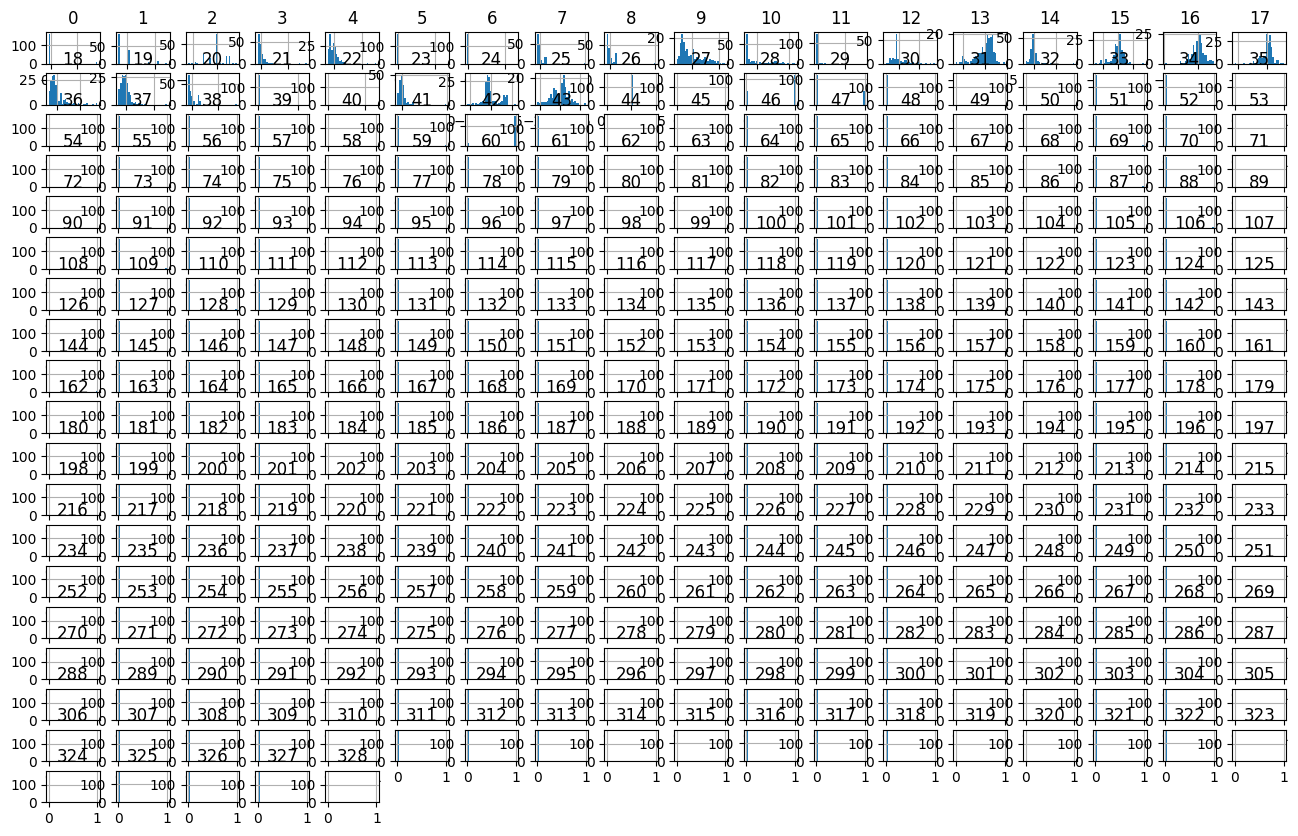

In [6]:
import matplotlib.pyplot as plt
processed_df.hist(figsize=(16, 10), bins=30)
plt.tight_layout()
plt.show()